In [1]:
!pip  install uproot 

In [ ]:
!xrdfs eospublic.cern.ch ls /eos/opendata/cms/Run2016H/DoubleMuon/NANOAOD/UL2016_MiniAODv2_NanoAODv9-v1/2510000/

In [177]:
!xrdfs eospublic.cern.ch ls /eos/opendata/cms/Run2012B/DoublePhoton/AOD/22Jan2013-v1/20015/

/eos/opendata/cms/Run2012B/DoublePhoton/AOD/22Jan2013-v1/20015/4682969C-1C6D-E211-9E1A-003048678E80.root


import uproot 

In [14]:
#file_path = "root://cms-xrd-global.cern.ch//eos/opendata/cms/Run2016H/DoubleMuon/NANOAOD/UL2016_MiniAODv2_NanoAODv9-v1/2510000/127C2975-1B1C-A046-AABF-62B77E757A86.root"
file_path = "root://eospublic.cern.ch//eos/opendata/cms/Run2016H/DoubleMuon/NANOAOD/UL2016_MiniAODv2_NanoAODv9-v1/2510000/127C2975-1B1C-A046-AABF-62B77E757A86.root"


In [16]:
tree = uproot.open(file_path + ":Events")
    # Access contents within this block
print(f"Keys in the file: {tree.keys()}")

Keys in the file: ['run', 'luminosityBlock', 'event', 'nboostedTau', 'boostedTau_chargedIso', 'boostedTau_eta', 'boostedTau_leadTkDeltaEta', 'boostedTau_leadTkDeltaPhi', 'boostedTau_leadTkPtOverTauPt', 'boostedTau_mass', 'boostedTau_neutralIso', 'boostedTau_phi', 'boostedTau_photonsOutsideSignalCone', 'boostedTau_pt', 'boostedTau_puCorr', 'boostedTau_rawAntiEle2018', 'boostedTau_rawIso', 'boostedTau_rawIsodR03', 'boostedTau_rawMVAnewDM2017v2', 'boostedTau_rawMVAoldDM2017v2', 'boostedTau_rawMVAoldDMdR032017v2', 'boostedTau_charge', 'boostedTau_decayMode', 'boostedTau_jetIdx', 'boostedTau_rawAntiEleCat2018', 'boostedTau_idAntiEle2018', 'boostedTau_idAntiMu', 'boostedTau_idMVAnewDM2017v2', 'boostedTau_idMVAoldDM2017v2', 'boostedTau_idMVAoldDMdR032017v2', 'CaloMET_phi', 'CaloMET_pt', 'CaloMET_sumEt', 'ChsMET_phi', 'ChsMET_pt', 'ChsMET_sumEt', 'nCorrT1METJet', 'CorrT1METJet_area', 'CorrT1METJet_eta', 'CorrT1METJet_muonSubtrFactor', 'CorrT1METJet_phi', 'CorrT1METJet_rawPt', 'DeepMETResolutio

In [17]:
branches = tree.arrays(
    ["Muon_pt", "Muon_eta", "Muon_phi", "Muon_mass"],
    entry_stop=5000   # small for testing
)

In [29]:
import numpy as np
pt = branches["Muon_pt"]
eta = branches["Muon_eta"]
phi = branches["Muon_phi"]
mass = branches["Muon_mass"]

px = pt * np.cos(phi)
py = pt * np.sin(phi)
pz = pt * np.sinh(eta)

E = np.sqrt(px**2 + py**2 + pz**2 + mass**2)

In [28]:
print(E)

[[187, 96.4, 132, 123, 93.6, 206], [1.85e+03, ...], ..., [89.3, 59.9, 11.6]]


In [61]:
import awkward as ak
mask = ak.num(pt) >= 3

px = px[mask]
py = py[mask]
pz = pz[mask]
E = E[mask]

px1 = px[:, 0]
py1 = py[:, 0]
pz1 = pz[:, 0]
E1 = E[:, 0]

px2 = px[:, 1]
py2 = py[:, 1]
pz2 = pz[:, 1]
E2 = E[:, 1]

In [32]:
mass2 = (E1 + E2)**2 - (
    (px1 + px2)**2 +
    (py1 + py2)**2 +
    (pz1 + pz2)**2
)

m = np.sqrt(mass2)

In [33]:
print('mass', m)

mass [24.5, 39.8, 275, 532, 8.59e+03, 1.21e+04, ..., 10, 17.7, 19.4, 23.1, 1.68]


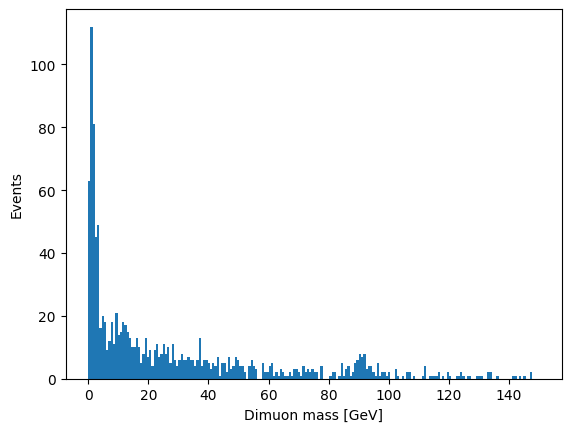

In [37]:
import matplotlib.pyplot as plt

plt.hist(ak.to_numpy(m), bins=200, range=(0,150))
plt.xlabel("Dimuon mass [GeV]")
plt.ylabel("Events")
plt.show()

In [69]:
### Lets say diphoton 

file_path_doubleEG = "root://eospublic.cern.ch//eos/opendata/cms/Run2016H/DoubleEG/NANOAOD/UL2016_MiniAODv2_NanoAODv9-v1/2500000/FB3ADF2F-FE4D-0944-A100-FA1D03041D4F.root"
tree_photon = uproot.open(file_path + ":Events")
print(f"Keys in the file: {tree_photon.keys()}")


Keys in the file: ['run', 'luminosityBlock', 'event', 'nboostedTau', 'boostedTau_chargedIso', 'boostedTau_eta', 'boostedTau_leadTkDeltaEta', 'boostedTau_leadTkDeltaPhi', 'boostedTau_leadTkPtOverTauPt', 'boostedTau_mass', 'boostedTau_neutralIso', 'boostedTau_phi', 'boostedTau_photonsOutsideSignalCone', 'boostedTau_pt', 'boostedTau_puCorr', 'boostedTau_rawAntiEle2018', 'boostedTau_rawIso', 'boostedTau_rawIsodR03', 'boostedTau_rawMVAnewDM2017v2', 'boostedTau_rawMVAoldDM2017v2', 'boostedTau_rawMVAoldDMdR032017v2', 'boostedTau_charge', 'boostedTau_decayMode', 'boostedTau_jetIdx', 'boostedTau_rawAntiEleCat2018', 'boostedTau_idAntiEle2018', 'boostedTau_idAntiMu', 'boostedTau_idMVAnewDM2017v2', 'boostedTau_idMVAoldDM2017v2', 'boostedTau_idMVAoldDMdR032017v2', 'CaloMET_phi', 'CaloMET_pt', 'CaloMET_sumEt', 'ChsMET_phi', 'ChsMET_pt', 'ChsMET_sumEt', 'nCorrT1METJet', 'CorrT1METJet_area', 'CorrT1METJet_eta', 'CorrT1METJet_muonSubtrFactor', 'CorrT1METJet_phi', 'CorrT1METJet_rawPt', 'DeepMETResolutio

In [141]:
### Lets say diphoton 
branches = tree_photon.arrays(
    ["Photon_pt", "Photon_eta", "Photon_phi", "Photon_mass", "nPhoton", "Photon_cutBased"],
    entry_stop=None
)

pt_photon = branches["Photon_pt"]
eta_photon = branches["Photon_eta"]
phi_photon = branches["Photon_phi"]
mass_photon = branches["Photon_mass"]
nphotons = branches["nPhoton"]
photon_id = branches["Photon_cutBased"]
print(nphotons)

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..., 0, 2, 0, 0, 0, 0, 0, 0, 2, 1, 0, 0]


In [154]:
mask_ID = photon_id >= 1  # keeps tight photons
pt_photon = pt_photon[mask_ID]
eta_photon = eta_photon[mask_ID]
phi_photon = phi_photon[mask_ID]
mass_photon = mass_photon[mask_ID]

In [155]:
mask_n2 = ak.num(pt_photon) >= 2
pt_photon   = pt_photon[mask_n2]
eta_photon  = eta_photon[mask_n2]
phi_photon  = phi_photon[mask_n2]
mass_photon = mass_photon[mask_n2]




In [156]:
#mask = nphotons >= 2
#mask = ((pt_photon[:,0] > 55) & (pt_photon[:,1] > 40) & (abs(eta_photon[:,0]) < 2.5) & (abs(eta_photon[:,1]) < 2.5))
#branches = branches[mask]
mask_kin = (pt_photon[:,0] > 25) & (pt_photon[:,1] > 20) & \
           (abs(eta_photon[:,0]) < 2.5) & (abs(eta_photon[:,1]) < 2.5)
pt_photon = pt_photon[mask_kin]
eta_photon = eta_photon[mask_kin]
phi_photon = phi_photon[mask_kin]
mass_photon = mass_photon[mask_kin]

n_events_2plus = len(pt_photon)
print("Events with ≥2 photons:", n_events_2plus)

Events with ≥2 photons: 388755


In [157]:
px_photon = pt_photon * np.cos(phi_photon)
py_photon = pt_photon * np.sin(phi_photon)
pz_photon = pt_photon * np.sinh(eta_photon)

E_photon = np.sqrt(px_photon**2 + py_photon**2 + pz_photon**2 + mass_photon**2)


In [158]:
px1_photon = px_photon[:,0]
py1_photon = py_photon[:,0]
pz1_photon = pz_photon[:,0]
E1_photon = E_photon[:,0]

px2_photon = px_photon[:,1]
py2_photon = py_photon[:,1]
pz2_photon = pz_photon[:,1]
E2_photon = E_photon[:,1]

In [159]:
mass2_photon = (E1_photon+E2_photon)**2 - (
    (px1_photon+px2_photon)**2 +
    (py1_photon+py2_photon)**2 +
    (pz1_photon+pz2_photon)**2
)

m_photon = np.sqrt(mass2_photon)
check_higgs = m_photon >125 


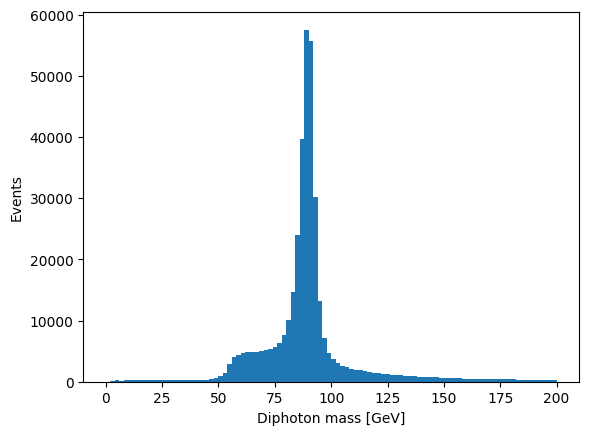

In [160]:
import matplotlib.pyplot as plt

plt.hist(ak.to_numpy(m_photon), bins=100, range=(0,200))
plt.xlabel("Diphoton mass [GeV]")
plt.ylabel("Events")
plt.show()

In [153]:
### ADD MULTIPLE FILES 
file_list = [
    "root://eospublic.cern.ch//eos/opendata/cms/Run2016H/DoubleEG/NANOAOD/UL2016_MiniAODv2_NanoAODv9-v1/100000/2AD46B56-E1CA-CD44-B30D-C57FE1C35D15.root",
    "root://eospublic.cern.ch//eos/opendata/cms/Run2016H/DoubleEG/NANOAOD/UL2016_MiniAODv2_NanoAODv9-v1/100000/61906161-574B-F749-859E-EF41556352AF.root",
    "root://eospublic.cern.ch//eos/opendata/cms/Run2016H/DoubleEG/NANOAOD/UL2016_MiniAODv2_NanoAODv9-v1/100000/B7CFAE74-1E82-C943-AF64-1C905145E477.root",
    "root://eospublic.cern.ch//eos/opendata/cms/Run2016H/DoubleEG/NANOAOD/UL2016_MiniAODv2_NanoAODv9-v1/100000/BA5BE5BB-A290-9749-9702-89E4A4A21F8F.root",
    "root://eospublic.cern.ch//eos/opendata/cms/Run2016H/DoubleEG/NANOAOD/UL2016_MiniAODv2_NanoAODv9-v1/100000/E0464771-1987-AF4F-9B88-A80064D90B18.root",
]

import uproot
import awkward as ak

# Open all files as a single chain
tree_list = [uproot.open(f)["Events"] for f in file_list]

# Concatenate branches from all files
pt_photon   = ak.concatenate([tree["Photon_pt"].array() for tree in tree_list])
eta_photon  = ak.concatenate([tree["Photon_eta"].array() for tree in tree_list])
phi_photon  = ak.concatenate([tree["Photon_phi"].array() for tree in tree_list])
mass_photon = ak.concatenate([tree["Photon_mass"].array() for tree in tree_list])
photon_id   = ak.concatenate([tree["Photon_cutBased"].array() for tree in tree_list])